In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

def load (path):
    df = pd.read_csv(path)
    return df

file_path = "/kaggle/input/fraud-detection/fraudTrain.csv"

df = load (file_path)

df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [2]:
def check_nulls(df): 
 return df.isnull().sum()
    
print("Null values in each column:\n")
print(check_nulls(df))

Null values in each column:

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [3]:
def drop_columns(df):
    
    cols_to_drop = ["Unnamed: 0", "trans_num", "cc_num", "unix_time", "first", "last"]
    df = df.drop(columns=cols_to_drop, errors="ignore")
    return df

df = drop_columns(df)
print("Columns dropped successfully!")


Columns dropped successfully!


In [4]:
def extract_time_features(df):
   
    # Convert to datetime if not already
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

    # Hour of the day (0–23)
    df['hour'] = df['trans_date_trans_time'].dt.hour
    
    # Day of the week (0 = Monday, 6 = Sunday)
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    
    # Weekend flag (1 = weekend, 0 = weekday)
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # Month (1–12)
    df['month'] = df['trans_date_trans_time'].dt.month
    
    return df
    
df = extract_time_features(df)
print(df[['trans_date_trans_time', 'hour', 'day_of_week', 'is_weekend', 'month']].head())


  trans_date_trans_time  hour  day_of_week  is_weekend  month
0   2019-01-01 00:00:18     0            1           0      1
1   2019-01-01 00:00:44     0            1           0      1
2   2019-01-01 00:00:51     0            1           0      1
3   2019-01-01 00:01:16     0            1           0      1
4   2019-01-01 00:03:06     0            1           0      1


# Feature Engineering

In [5]:
def extract_age(df, reference_date=None):
   
    # Convert to datetime
    df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
    
    if reference_date is None:
        reference_date = pd.to_datetime(df['trans_date_trans_time']).max()
    else:
        reference_date = pd.to_datetime(reference_date)  

    df['age'] = reference_date.year - df['dob'].dt.year    
   
    mask = ( (reference_date.month < df['dob'].dt.month) | 
             ((reference_date.month == df['dob'].dt.month) & (reference_date.day < df['dob'].dt.day)) )
    df.loc[mask, 'age'] = df.loc[mask, 'age'] - 1
    
  
    df = df.drop(columns=['dob'], errors="ignore")
    
    return df


df = extract_age(df)
print(df[['age']].head())

   age
0   32
1   42
2   58
3   53
4   34


In [6]:
def add_distance_feature(df):
    
    # Convert degrees to radians
    lat1 = np.radians(df['lat'])
    lon1 = np.radians(df['long'])
    lat2 = np.radians(df['merch_lat'])
    lon2 = np.radians(df['merch_long'])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Earth radius ~6371 km
    df['distance_km'] = 6371 * c
    
    return df

df = add_distance_feature(df)
df[['lat', 'long', 'merch_lat', 'merch_long', 'distance_km']].head()

,lat,long,merch_lat,merch_long,distance_km
0,36.0788,-81.1781,36.011293,-82.048315,78.597568
1,48.8878,-118.2105,49.159047,-118.186462,30.212176
2,42.1808,-112.2620,43.150704,-112.154481,108.206083
3,46.2306,-112.1138,47.034331,-112.561071,95.673231
4,38.4207,-79.4629,38.674999,-78.632459,77.556744


In [7]:
def encode_features(df):
   
    for col in ['city', 'state', 'zip', 'job', 'merchant','street']:
        if col in df.columns:
            freq = df[col].value_counts()
            df[col + '_freq_enc'] = df[col].map(freq)
            df = df.drop(columns=[col])  
    return df

df = encode_features(df)
df.head()

,trans_date_trans_time,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,...,is_weekend,month,age,distance_km,city_freq_enc,state_freq_enc,zip_freq_enc,job_freq_enc,merchant_freq_enc,street_freq_enc
0,2019-01-01 00:00:18,misc_net,4.97,F,36.0788,-81.1781,3495,36.011293,-82.048315,0,...,0,1,32,78.597568,2028,30266,2028,3545,1267,2028
1,2019-01-01 00:00:44,grocery_pos,107.23,F,48.8878,-118.2105,149,49.159047,-118.186462,0,...,0,1,42,30.212176,3545,18924,3030,5099,2503,3030
2,2019-01-01 00:00:51,entertainment,220.11,M,42.1808,-112.2620,4154,43.150704,-112.154481,0,...,0,1,58,108.206083,503,5545,503,511,1895,503
3,2019-01-01 00:01:16,gas_transport,45.00,M,46.2306,-112.1138,1939,47.034331,-112.561071,0,...,0,1,53,95.673231,493,11754,493,2530,2613,493
4,2019-01-01 00:03:06,misc_pos,41.96,M,38.4207,-79.4629,99,38.674999,-78.632459,0,...,0,1,34,77.556744,2017,29250,2017,2017,1592,2017


In [8]:
def one_hot_encode_category(df):

    if 'category' in df.columns:
        dummies = pd.get_dummies(df['category'], prefix='cat')
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(columns=['category'])
    return df

df = one_hot_encode_category(df)
print("done")

done


In [9]:
def encode_gender(df):
    
    if 'gender' in df.columns:
        df['gender_enc'] = df['gender'].map({'M': 0, 'F': 1})
        df = df.drop(columns=['gender'])
    return df

df = encode_gender(df)
print(df[['gender_enc']].head())

   gender_enc
0           1
1           1
2           0
3           0
4           0


In [10]:
def detect_outliers_iqr(df, column):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers, low, high = detect_outliers_iqr(df, "amt")
print(f"Outliers detected: {len(outliers)}")
outliers.head()

Outliers detected: 67290


,trans_date_trans_time,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day_of_week,...,cat_health_fitness,cat_home,cat_kids_pets,cat_misc_net,cat_misc_pos,cat_personal_care,cat_shopping_net,cat_shopping_pos,cat_travel,gender_enc
2,2019-01-01 00:00:51,220.11,42.1808,-112.2620,4154,43.150704,-112.154481,0,0,1,...,False,False,False,False,False,False,False,False,False,0
9,2019-01-01 00:06:01,198.39,36.5220,-87.3490,151785,37.179198,-87.485381,0,0,1,...,False,False,False,False,False,False,False,False,False,1
16,2019-01-01 00:10:49,327.00,36.3850,-98.0727,1078,36.384092,-99.048472,0,0,1,...,False,False,False,True,False,False,False,False,False,1
17,2019-01-01 00:10:58,341.67,38.9763,-87.3667,4081,38.674491,-88.305767,0,0,1,...,False,False,False,False,False,False,False,True,False,0
36,2019-01-01 00:26:22,207.36,40.6729,-73.5365,34496,40.202538,-73.859212,0,0,1,...,False,False,False,False,False,False,False,False,False,1


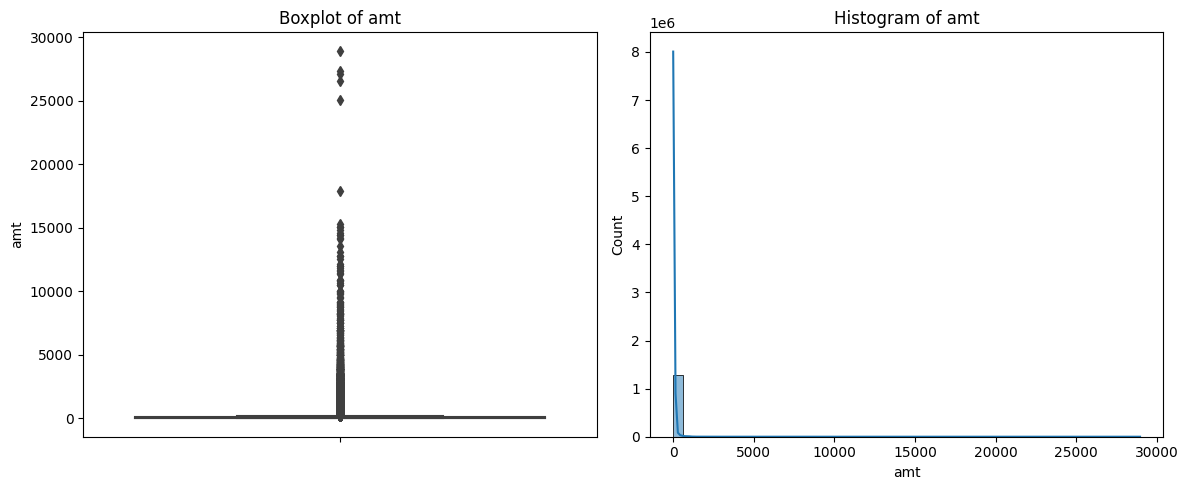

In [11]:
def plot_outliers(df, column):
   
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Boxplot
    sns.boxplot(y=df[column], ax=axes[0])
    axes[0].set_title(f"Boxplot of {column}")

    # Histogram
    sns.histplot(df[column], bins=50, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram of {column}")

    plt.tight_layout()
    plt.show()

# Example usage
plot_outliers(df, "amt")

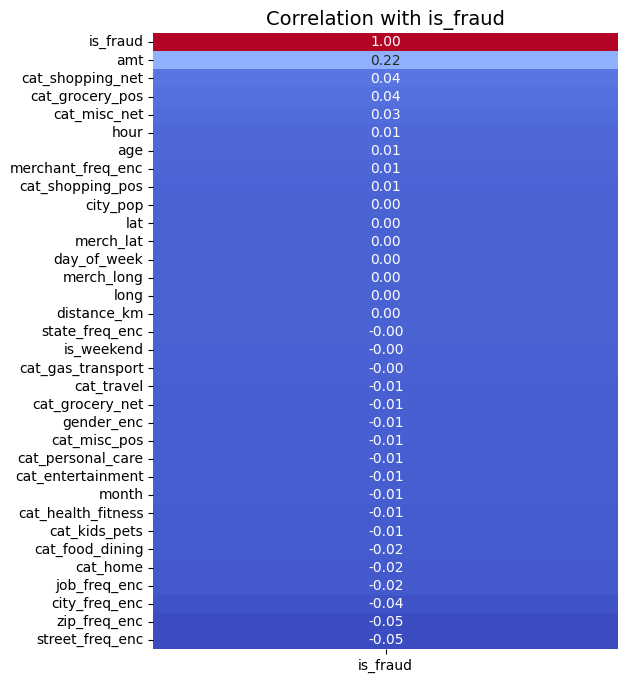

                    is_fraud
is_fraud            1.000000
amt                 0.219404
cat_shopping_net    0.044261
cat_grocery_pos     0.035558
cat_misc_net        0.025886
hour                0.013799
age                 0.012411
merchant_freq_enc   0.007968
cat_shopping_pos    0.005955
city_pop            0.002136
lat                 0.001894
merch_lat           0.001741
day_of_week         0.001739
merch_long          0.001721
long                0.001721
distance_km         0.000403
state_freq_enc     -0.000353
is_weekend         -0.003644
cat_gas_transport  -0.004851
cat_travel         -0.006924
cat_grocery_net    -0.007136
gender_enc         -0.007642
cat_misc_pos       -0.008937
cat_personal_care  -0.012167
cat_entertainment  -0.012200
month              -0.012409
cat_health_fitness -0.014885
cat_kids_pets      -0.014967
cat_food_dining    -0.015025
cat_home           -0.017848
job_freq_enc       -0.020476
city_freq_enc      -0.038308
zip_freq_enc       -0.052288
street_freq_en

In [12]:
def fraud_target_correlation(df, target_col="is_fraud"):
    
    corr = df.corr(numeric_only=True)[[target_col]].sort_values(by=target_col, ascending=False)

    # Plot heatmap
    plt.figure(figsize=(6, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=False)
    plt.title(f"Correlation with {target_col}", fontsize=14)
    plt.show()

    return corr

fraud_corr = fraud_target_correlation(df, target_col="is_fraud")
print(fraud_corr)

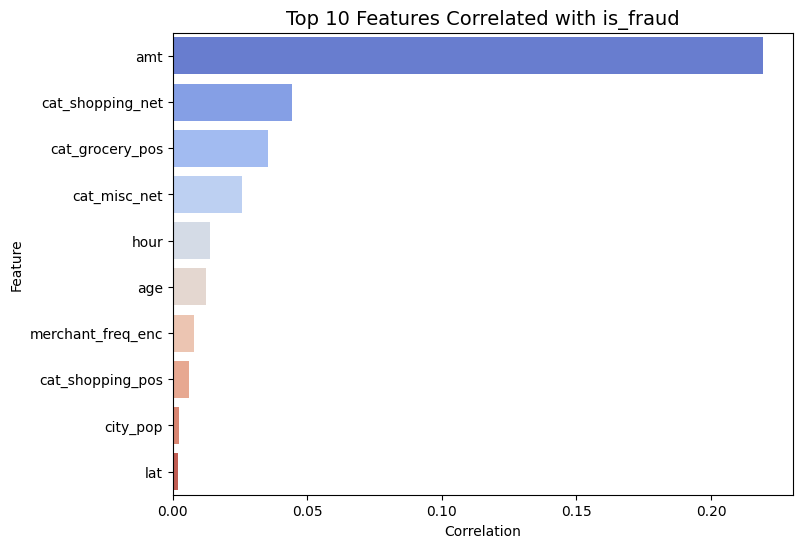

In [13]:
def plot_top_corr_with_fraud(corr_df, target_col="is_fraud", top_n=10):
    
    # Drop target itself
    corr_sorted = corr_df.drop(index=target_col).sort_values(by=target_col, ascending=False)

    # Top N features
    top_features = corr_sorted.head(top_n)

    # Barplot
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_features[target_col], y=top_features.index, palette="coolwarm")
    plt.title(f"Top {top_n} Features Correlated with {target_col}", fontsize=14)
    plt.xlabel("Correlation")
    plt.ylabel("Feature")
    plt.show()

# Example usage
# fraud_corr = fraud_target_correlation(df, target_col="is_fraud")
plot_top_corr_with_fraud(fraud_corr, target_col="is_fraud", top_n=10)

In [14]:
def drop_trans_date_trans_time(df):
    
    cols_to_drop = ["trans_date_trans_time"]
    df = df.drop(columns=cols_to_drop, errors="ignore")
    return df

df = drop_trans_date_trans_time(df)
print("Dropped successfully!")


Dropped successfully!


In [15]:
def scale_numerical_features(df, num_cols):
    
    df_scaled = df.copy()
    scaler = StandardScaler()
    
    # Only scale columns that exist in df
    cols_to_scale = [col for col in num_cols if col in df_scaled.columns]
    
    df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])
    
    return df_scaled, scaler

num_cols = [
    'amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long',
    'is_weekend', 'distance_km', 'city_freq_enc', 'state_freq_enc',
    'zip_freq_enc', 'job_freq_enc', 'merchant_freq_enc', 'street_freq_enc',
    'gender_enc'
]

df_scaled, scaler = scale_numerical_features(df, num_cols)

df_scaled[num_cols].head()

,amt,lat,long,city_pop,merch_lat,merch_long,is_weekend,distance_km,city_freq_enc,state_freq_enc,zip_freq_enc,job_freq_enc,merchant_freq_enc,street_freq_enc,gender_enc
0,-0.407826,-0.484420,0.657620,-0.282589,-0.494354,0.593864,-0.730941,0.085274,-0.035666,-0.420291,0.230979,-0.194873,-1.472203,0.281849,0.909206
1,0.230039,2.039120,-2.033870,-0.293670,2.078699,-2.030341,-0.730941,-1.576488,1.477953,-0.865412,1.537699,0.574734,0.858371,1.631335,0.909206
2,0.934149,0.717754,-1.601537,-0.280406,0.902849,-1.592323,-0.730941,1.102157,-1.557268,-1.390476,-1.757792,-1.697439,-0.288060,-1.772008,-1.099861
3,-0.158132,1.515617,-1.590766,-0.287742,1.662886,-1.621848,-0.730941,0.671726,-1.567246,-1.146801,-1.770833,-0.697544,1.065784,-1.785476,-1.099861
4,-0.177094,-0.023035,0.782279,-0.293835,0.026941,0.841909,-0.730941,0.049528,-0.046642,-0.460164,0.216633,-0.951604,-0.859390,0.267035,-1.099861


In [16]:
from sklearn.model_selection import train_test_split

def stratified_train_test_split(df, target_col="is_fraud", test_size=0.2, random_state=42):
   
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    return X_train, X_test, y_train, y_test

# Example usage
# df = pd.read_csv("fraud_dataset.csv")
X_train, X_test, y_train, y_test = stratified_train_test_split(df, target_col="is_fraud")

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Fraud ratio in Train:", y_train.mean())
print("Fraud ratio in Test:", y_test.mean())


Train shape: (1037340, 33)  Test shape: (259335, 33)
Fraud ratio in Train: 0.00578884454470087
Fraud ratio in Test: 0.005787880540613492


# ML Modeling

In [17]:
def train_logistic_regression(df, target_col="is_fraud", test_size=0.2, random_state=42):
    
    # Split dataset
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    # Logistic Regression with balanced weights
    model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state)
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print(f"ROC-AUC: {auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    return model

# Train logistic regression
log_reg_model = train_logistic_regression(df, target_col="is_fraud")

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97    257834
           1       0.07      0.76      0.12      1501

    accuracy                           0.94    259335
   macro avg       0.53      0.85      0.54    259335
weighted avg       0.99      0.94      0.96    259335

ROC-AUC: 0.8822
F1-Score: 0.1215

Confusion Matrix:
 [[241672  16162]
 [   359   1142]]


In [18]:
def train_xgboost(df, target_col="is_fraud", test_size=0.2, random_state=42):
 
    # Split dataset
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    # Calculate imbalance ratio
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    # XGBoost model
    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,  # handle imbalance
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=random_state,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    
    print("=== XGBoost Performance ===")
    print("ROC-AUC:", round(auc, 4))
    print("F1-Score:", round(f1, 4))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    return model

xgb_model = train_xgboost(df_scaled, target_col="is_fraud")

=== XGBoost Performance ===
ROC-AUC: 0.9992
F1-Score: 0.695

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.54      0.96      0.69      1501

    accuracy                           1.00    259335
   macro avg       0.77      0.98      0.85    259335
weighted avg       1.00      1.00      1.00    259335


Confusion Matrix:
 [[256616   1218]
 [    53   1448]]


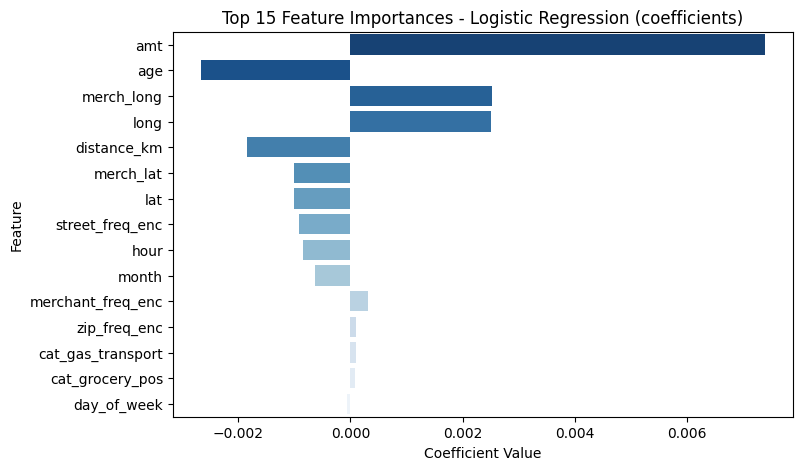

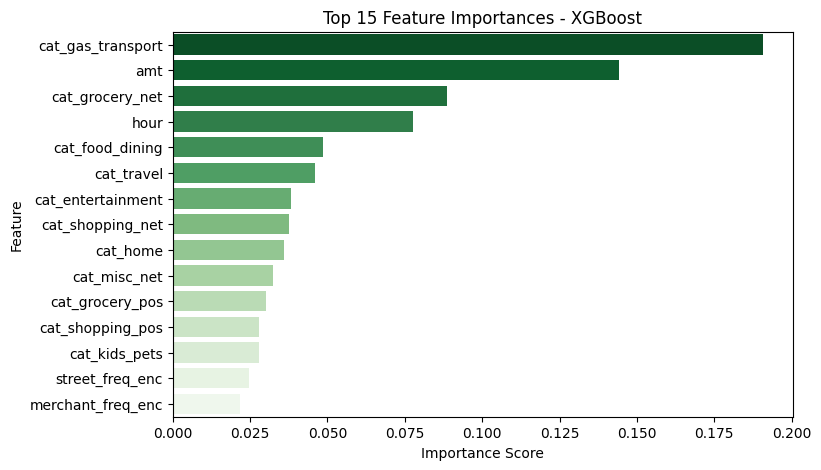

In [19]:
def plot_feature_importance(X_train, y_train):
    # Logistic Regression
    log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    log_reg.fit(X_train, y_train)
    
    coef_importance = pd.Series(log_reg.coef_[0], index=X_train.columns)
    coef_importance = coef_importance.sort_values(key=abs, ascending=False)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(x=coef_importance.values[:15], y=coef_importance.index[:15], palette="Blues_r")
    plt.title("Top 15 Feature Importances - Logistic Regression (coefficients)")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Feature")
    plt.show()
    
    # XGBoost
    xgb = XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
    )
    xgb.fit(X_train, y_train)
    
    xgb_importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
    xgb_importance = xgb_importance.sort_values(ascending=False)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(x=xgb_importance.values[:15], y=xgb_importance.index[:15], palette="Greens_r")
    plt.title("Top 15 Feature Importances - XGBoost")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.show()

plot_feature_importance(X_train, y_train)

# Comparing and Verifying Model Results


In [20]:
def train_logistic_xgb(X_train, X_test, y_train, y_test):
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
        "XGBoost": XGBClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, use_label_encoder=False,
            eval_metric="logloss",
            scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
        )
    }
    
    results = []
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "Confusion Matrix": confusion_matrix(y_test, y_pred)
        })
    
    return pd.DataFrame(results)

comparison_table = train_logistic_xgb(X_train, X_test, y_train, y_test)
print(comparison_table)

                 Model  Accuracy  Precision    Recall  F1-Score  \
0  Logistic Regression  0.936295   0.065996  0.760826  0.121457   
1              XGBoost  0.992469   0.432818  0.970020  0.598561   

                 Confusion Matrix  
0  [[241672, 16162], [359, 1142]]  
1    [[255926, 1908], [45, 1456]]  
